In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('/Users/eri/Desktop/youtube_videos.csv')


print(df.shape)      
df.head()            

(210, 18)


,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"


In [5]:
scaler = MinMaxScaler()

df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

df["subscribers_minmax"]

0      0.056122
1      0.002541
2      0.308431
3      0.063485
4      0.003147
         ...   
205    0.001006
206    0.000565
207    0.061652
208    0.000814
209    0.070625
Name: subscribers_minmax, Length: 210, dtype: float64

In [6]:
df["subscribers_minmax"].describe()

count    210.000000
mean       0.128853
std        0.265999
min        0.000000
25%        0.002555
50%        0.016794
75%        0.061946
max        1.000000
Name: subscribers_minmax, dtype: float64

In [8]:
standard_scaler = StandardScaler()
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [9]:
df[["views", "view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

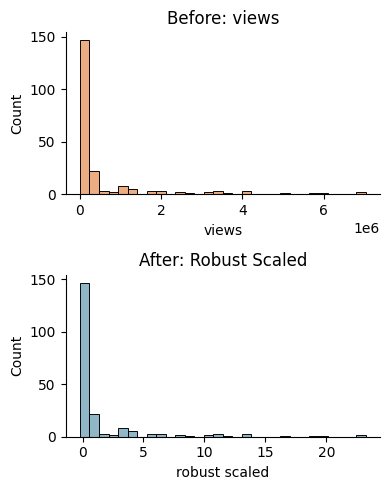

In [12]:
scaler = RobustScaler()
df["views_robust"] = scaler.fit_transform(df[["views"]])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["views_robust"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: Robust Scaled")
axes[1].set_xlabel("robust scaled")

sns.despine()
plt.tight_layout()
plt.show()

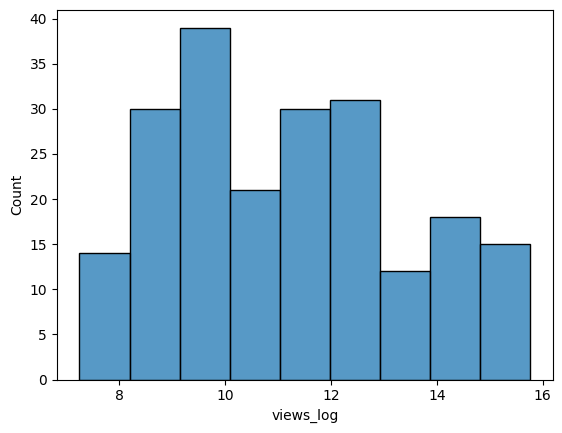

In [13]:
import numpy as np

df["views_log"] = np.log1p(df["views"])
sns.histplot(df["views_log"])
plt.show()

In [14]:
bins = [0, 300, 2000, float("inf")]
labels = ['short', "medium", "long"]

df["duration_bin"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)

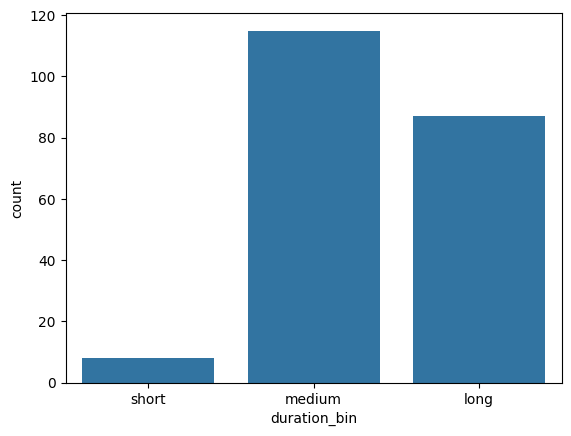

In [15]:
sns.countplot(data=df, x="duration_bin", order=["short", "medium", "long"])
plt.show()

In [18]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]])

In [19]:
df[["channel_tier", "channel_tier_encoded"]]

,channel_tier,channel_tier_encoded
0,Mid,1.0
1,Small,0.0
2,Large,2.0
3,Mid,1.0
4,Small,0.0
...,...,...
205,Small,0.0
206,Small,0.0
207,Mid,1.0
208,Small,0.0


In [21]:
dummyVars = pd.get_dummies(df["category"], prefix="is")
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [22]:
df = pd.concat([df, dummyVars], axis=1)

In [23]:
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [24]:
import numpy as np

day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

In [25]:
df["uploaded_at"]

0     2024-01-07 00:05:00
1     2024-01-06 21:46:00
2     2024-01-08 18:39:00
3     2024-01-04 14:26:00
4     2024-01-08 04:25:00
              ...        
205   2024-01-05 13:15:00
206   2024-01-06 08:45:00
207   2024-01-07 20:58:00
208   2024-01-04 21:15:00
209   2024-01-05 10:46:00
Name: uploaded_at, Length: 210, dtype: datetime64[ns]

In [26]:
df["uploaded_at"].dt.dayofweek

0      6
1      5
2      0
3      3
4      0
      ..
205    4
206    5
207    6
208    3
209    4
Name: uploaded_at, Length: 210, dtype: int32

In [29]:
def countCaps(t):
    return sum(1 for w in t.split() if w[0].isupper())

df["caps_count"] = df["title"].apply(countCaps)

df["caps_count"]


0      3
1      2
2      1
3      2
4      4
      ..
205    4
206    2
207    2
208    3
209    3
Name: caps_count, Length: 210, dtype: int64

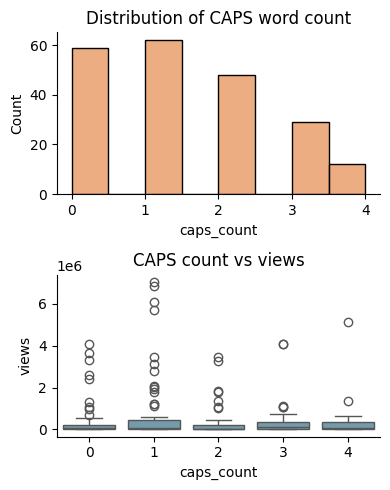

In [31]:
df["caps_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.isupper())
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["caps_count"],
             bins=8,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of CAPS word count")
axes[0].set_xlabel("caps_count")

sns.boxplot(data=df,
            x="caps_count",
            y="views",
            color="#6a9fb5",
            ax=axes[1])
axes[1].set_title("CAPS count vs views")
axes[1].set_xlabel("caps_count")
axes[1].set_ylabel("views")

sns.despine()
plt.tight_layout()
plt.show()

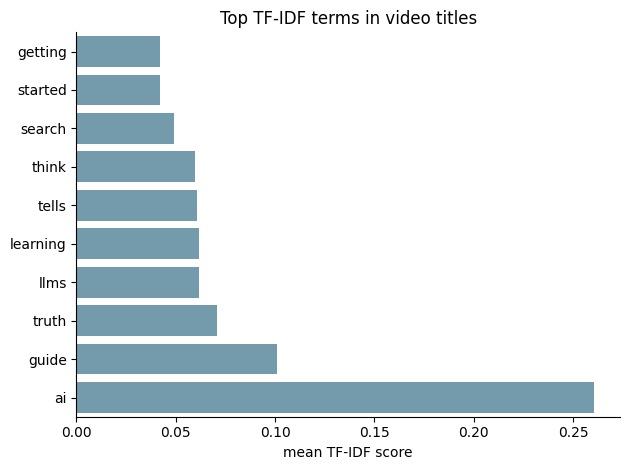

In [33]:
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

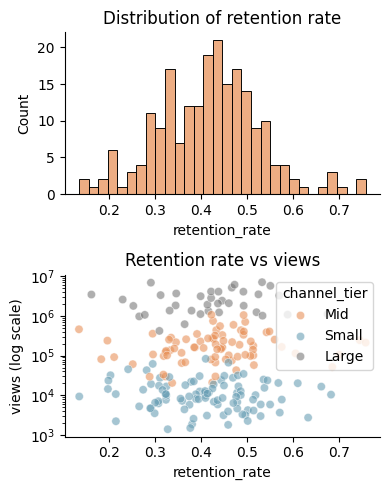

In [34]:


df["duration_minutes"] = df["duration_seconds"] / 60

df["retention_rate"] = (
    df["watch_time_minutes"] /
    (df["views"] * df["duration_minutes"])
).clip(0, 1)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["retention_rate"],
             bins=30,
             color="#e8925a",
             ax=axes[0])
axes[0].set_title("Distribution of retention rate")
axes[0].set_xlabel("retention_rate")

sns.scatterplot(data=df,
                x="retention_rate",
                y="views",
                hue="channel_tier",
                palette={"Small": "#6a9fb5",
                         "Mid": "#e8925a",
                         "Large": "#7a7a7a"},
                alpha=0.6,
                ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Retention rate vs views")
axes[1].set_xlabel("retention_rate")
axes[1].set_ylabel("views (log scale)")

sns.despine()
plt.tight_layout()
plt.show()

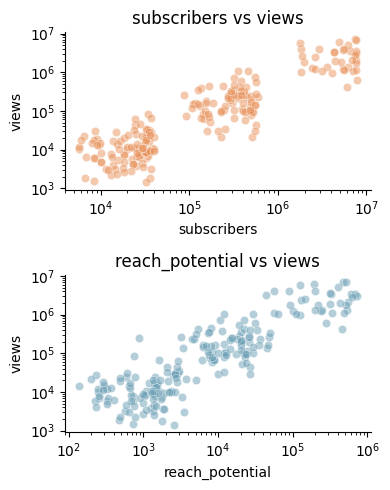

In [35]:
df["reach_potential"] = (
    df["subscribers"] * df["click_through_rate"]
)

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.scatterplot(data=df,
                x="subscribers",
                y="views",
                color="#e8925a",
                alpha=0.5,
                ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("subscribers vs views")

sns.scatterplot(data=df,
                x="reach_potential",
                y="views",
                color="#6a9fb5",
                alpha=0.5,
                ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("reach_potential vs views")

sns.despine()
plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)
result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

log = pd.read_csv('/Users/eri/Desktop/transformed_dataset.csv')
grades = pd.read_csv('/Users/eri/Desktop/grades_data.csv')

print(log.head(10))
print("*****")
print(grades.head(10))

   userID assignment                                                url  \
0  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
1  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
2  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
3  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
4  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-m...   
5  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
6  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
7  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
8  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
9  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   

                  start_time  view_length  
0  2026-05-20 16:19:42-07:00         22.0  
1  2026-05-20 16:20:49-07:00       1524.0  
2  2026-05-22 23:31:51-07:00         11.0 

In [2]:
# Count the number of page visits per student per assignment
# Then reshape so each assignment becomes its own column
grouped = log.groupby(['userID', 'assignment']).size().unstack(fill_value=0)
grouped = grouped.reindex(sorted(grouped.columns), axis=1)
grouped.columns = [f"{col}totalCount" for col in grouped.columns]
assignment_counts = grouped.reset_index()

print(f"Shape: {assignment_counts.shape}")
assignment_counts.head()

Shape: (54, 6)


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount
0,100001,38,37,37,61,48
1,100002,46,49,39,42,64
2,100003,38,33,37,24,29
3,100004,41,19,38,28,40
4,100005,27,52,51,27,51


In [3]:
# Sum view_length (seconds) per student per assignment
# Then merge with the count table to have both in one dataframe
time_totals = (
    log.groupby(['userID', 'assignment'])['view_length'].sum().unstack(fill_value=0)
)
time_totals = time_totals.reindex(sorted(time_totals.columns), axis=1)
time_totals.columns = [f"{col}totalTime" for col in time_totals.columns]
time_totals = time_totals.reset_index()

assignments = pd.merge(assignment_counts, time_totals, on='userID', how='left')

print(f"Final shape: {assignments.shape}")
print("Columns:", assignments.columns.tolist())
assignments.head()

Final shape: (54, 11)
Columns: ['userID', 'a1totalCount', 'a2totalCount', 'a3totalCount', 'a4totalCount', 'a5totalCount', 'a1totalTime', 'a2totalTime', 'a3totalTime', 'a4totalTime', 'a5totalTime']


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


In [4]:
grades = pd.merge(grades, assignments, on="userID", how='left')
print(f"Grades DataFrame shape: {grades.shape}")
grades.head()

Grades DataFrame shape: (54, 17)


,userID,A1,A2,A3,A4,A5,FinalScore,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,93.75,68.75,100.00,76.47,82.05,59.97,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,112.50,125.00,100.00,88.24,92.31,77.81,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,100.00,125.00,121.43,94.12,93.59,89.88,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,116.67,125.00,75.00,52.94,57.69,73.30,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,95.83,106.25,82.14,35.29,33.33,56.57,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


In [6]:
# Set a deadline date for each assignment
# These are used to calculate how many days before the deadline each student worked
log['start_time'] = pd.to_datetime(log['start_time'], utc=True)
log['date'] = log['start_time'].dt.date

deadlines = {
    'a1': pd.Timestamp('2026-06-01', tz='UTC'),
    'a2': pd.Timestamp('2026-06-15', tz='UTC'),
    'a3': pd.Timestamp('2026-06-29', tz='UTC'),
    'a4': pd.Timestamp('2026-07-13', tz='UTC'),
    'a5': pd.Timestamp('2026-07-27', tz='UTC'),
}

In [7]:
# For each (student, assignment) pair, calculate time-based features
# e.g. how many days before the deadline did they first start?
rows = []

for (user, assignment), group in log.groupby(['userID', 'assignment']):
    if assignment not in deadlines:
        continue

    deadline = deadlines[assignment]
    dates = sorted(set(group['date']))

    # How many days before the deadline each unique day falls
    days_before = [(deadline.date() - d).days for d in dates]

    # Days that fall within the final week before deadline
    days_in_last_week = [d for d in dates if 0 <= (deadline.date() - d).days <= 7]

    rows.append({
        'userID': user,
        'assignment': assignment,
        'firstDay': days_before[0] if len(days_before) >= 1 else None,
        'secondDay': days_before[1] if len(days_before) >= 2 else None,
        'firstSecondGap': (days_before[0] - days_before[1]) if len(days_before) >= 2 else None,
        'nDays': len(dates),
        'nDaysFinalWeek': len(days_in_last_week),
        'nDaysBeforeFinalWeek': len([d for d in days_before if d > 7]),
        'nDaysAfterDeadline': len([d for d in days_before if d < 0]),
    })

activity_summary = pd.DataFrame(rows)
print(f"activity dataframe shape: {activity_summary.shape}")
activity_summary.head(10)

activity dataframe shape: (263, 9)


,userID,assignment,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,a1,12,9.0,3.0,7,4,3,0
1,100001,a2,18,12.0,6.0,11,6,4,1
2,100001,a3,4,0.0,4.0,9,2,0,7
3,100001,a4,2,1.0,1.0,9,3,0,6
4,100001,a5,2,1.0,1.0,8,2,0,6
5,100002,a1,21,14.0,7.0,9,4,5,0
6,100002,a2,19,18.0,1.0,14,5,6,3
7,100002,a3,12,9.0,3.0,13,6,2,5
8,100002,a4,4,0.0,4.0,6,2,0,4
9,100002,a5,14,11.0,3.0,14,1,3,10


In [8]:
# Convert grades from wide to long format
# Each student-assignment pair becomes its own row
grades_long = pd.melt(
    grades[['userID', 'A1', 'A2', 'A3', 'A4', 'A5']],
    id_vars='userID',
    var_name='assignment_upper',
    value_name='grade'
)

grades_long['assignment'] = grades_long['assignment_upper'].str.lower()

grades_long.head()

,userID,assignment_upper,grade,assignment
0,100001,A1,93.75,a1
1,100002,A1,112.50,a1
2,100003,A1,100.00,a1
3,100004,A1,116.67,a1
4,100005,A1,95.83,a1


In [9]:
# Join activity_summary (temporal features) onto grades_long
# using both userID and assignment as keys
merged = pd.merge(grades_long, activity_summary, on=['userID', 'assignment'], how='left')

print(f"merged shape: {merged.shape}")
merged.head()

merged shape: (270, 11)


,userID,assignment_upper,grade,assignment,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,A1,93.75,a1,12.0,9.0,3.0,7.0,4.0,3.0,0.0
1,100002,A1,112.50,a1,21.0,14.0,7.0,9.0,4.0,5.0,0.0
2,100003,A1,100.00,a1,17.0,11.0,6.0,7.0,2.0,5.0,0.0
3,100004,A1,116.67,a1,11.0,6.0,5.0,5.0,3.0,1.0,1.0
4,100005,A1,95.83,a1,11.0,10.0,1.0,6.0,1.0,4.0,1.0


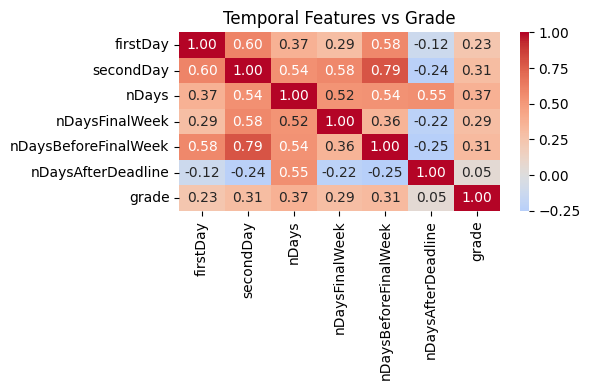

In [10]:
# Check how well temporal features correlate with grades
feature_cols = ['firstDay', 'secondDay', 'nDays', 'nDaysFinalWeek',
                'nDaysBeforeFinalWeek', 'nDaysAfterDeadline']

# Plot heatmap of correlations
plt.figure(figsize=(6, 4))
sns.heatmap(
    merged[feature_cols + ['grade']].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Temporal Features vs Grade')
plt.tight_layout()
plt.show()

In [11]:
# firstSecondGap can always be calculated from firstDay and secondDay
# Keeping it would cause collinearity (two features carrying the same info)
redundant = [c for c in merged.columns if 'firstSecondGap' in c]
merged = merged.drop(columns=redundant)

print('Dropped:', redundant)
print('Remaining columns:', merged.columns.tolist())

Dropped: ['firstSecondGap']
Remaining columns: ['userID', 'assignment_upper', 'grade', 'assignment', 'firstDay', 'secondDay', 'nDays', 'nDaysFinalWeek', 'nDaysBeforeFinalWeek', 'nDaysAfterDeadline']


In [12]:
# detailRatio = time spent on the detail-specification page / total time on all pages
# A higher ratio means the student spent more of their time reading the full spec
detail_time = (
    log[log['url'].str.contains('detail-specification')]
    .groupby(['userID', 'assignment'])['view_length']
    .sum()
)

total_time = log.groupby(['userID', 'assignment'])['view_length'].sum()

# Students who never visited the detail page get 0
detail_ratio = (detail_time / total_time).fillna(0).reset_index()
detail_ratio.columns = ['userID', 'assignment', 'detailRatio']

print(f"detail_ratio shape: {detail_ratio.shape}")
detail_ratio.head()

detail_ratio shape: (263, 3)


,userID,assignment,detailRatio
0,100001,a1,0.460360
1,100001,a2,0.664057
2,100001,a3,0.777936
3,100001,a4,0.560812
4,100001,a5,0.353889


In [13]:
# Add detailRatio to the merged dataframe
merged = pd.merge(merged, detail_ratio, on=['userID', 'assignment'], how='left')

print(f"merged shape after adding detailRatio: {merged.shape}")
merged[['userID', 'assignment', 'grade', 'detailRatio']].head(10)

merged shape after adding detailRatio: (270, 11)


,userID,assignment,grade,detailRatio
0,100001,a1,93.75,0.460360
1,100002,a1,112.50,0.701445
2,100003,a1,100.00,0.551575
3,100004,a1,116.67,0.462006
4,100005,a1,95.83,0.721157
5,100006,a1,70.83,0.522972
6,100007,a1,106.92,0.351631
7,100008,a1,77.08,0.497650
8,100009,a1,70.83,0.445889
9,100010,a1,108.33,0.553174


detailRatio vs grade:
  A1: r = 0.116
  A2: r = 0.369
  A3: r = 0.033
  A4: r = -0.25
  A5: r = 0.1


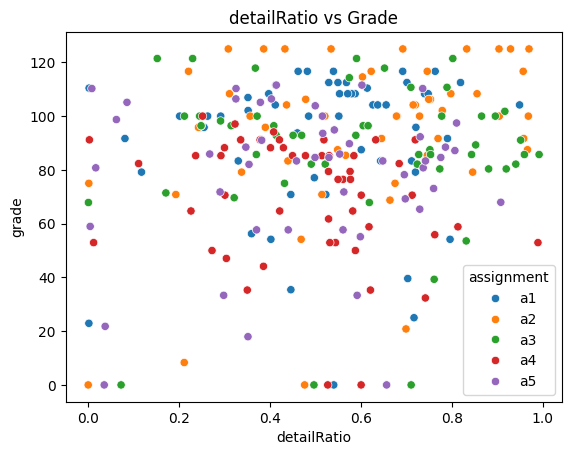

In [15]:
# Check if detailRatio correlates with grades
corr_results = {}
for i in range(1, 6):
    sub = merged[merged['assignment'] == f'a{i}'][['grade', 'detailRatio']].dropna()
    if len(sub) > 1:
        corr_results[f'A{i}'] = round(sub.corr().iloc[0, 1], 3)

print('detailRatio vs grade:')
for k, v in corr_results.items():
    print(f'  {k}: r = {v}')

# Scatter plot
sns.scatterplot(data=merged, x='detailRatio', y='grade', hue='assignment')
plt.title('detailRatio vs Grade')
plt.show()